**Logistic** **Regression**

Logistic Regression is a supervised machine learning algorithm used for
classification problems. Unlike linear regression, which predicts
continuous values it predicts the probability that an input belongs to a
specific class.

In [ ]:
import numpy as np
def sigmoid(x):
  return 1/(1+np.exp(-x))

In [ ]:
print(sigmoid(200))

1.0


In [ ]:
print(sigmoid(15))

0.999999694097773


In [ ]:
print(sigmoid(-5))

0.0066928509242848554


In [ ]:
# output range (0-1)
# Activation function
# Large data value gives in range (0-1)
# It works also as binary classification

# Threshold = pass/fail

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification # randomly dataset banauxa


In [ ]:
def generate_dataset():
  dataset = make_classification(n_samples=30, n_features = 1, n_repeated=0, n_redundant=0, shift = 30, scale = 10, n_classes = 2, n_clusters_per_class=1, n_informative=1, class_sep=1, random_state=1)
  df = pd.DataFrame(dataset[0])
  df = pd.concat([(np.ceil(df)).astype(int), pd.DataFrame(dataset[1])], axis =1)
  df.columns = ["GRE_Score", "Admission"]
  return df

In [ ]:
data = generate_dataset()
data.head()

,GRE_Score,Admission
0,287,0
1,295,0
2,317,1
3,300,0
4,310,1


<Axes: xlabel='GRE_Score', ylabel='Admission'>

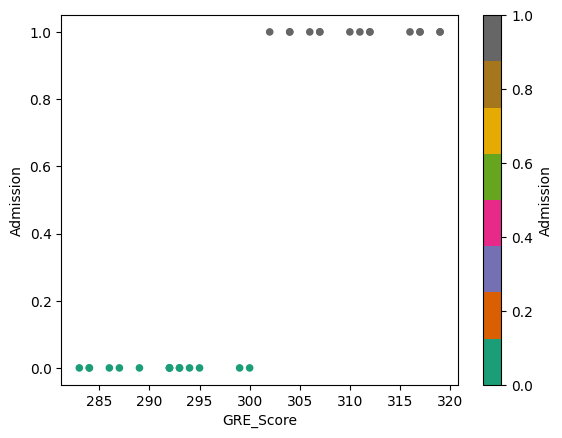

In [ ]:
data.plot.scatter(x = "GRE_Score", y = "Admission", c="Admission",cmap = "Dark2")

In [ ]:

from sklearn.linear_model import LinearRegression
map_color = np.array(["r","b"])
x = data[["GRE_Score"]].to_numpy()
y = data[["Admission"]].to_numpy()

In [ ]:
linear_reg = LinearRegression()
linear_reg.fit(x,y)

LinearRegression()

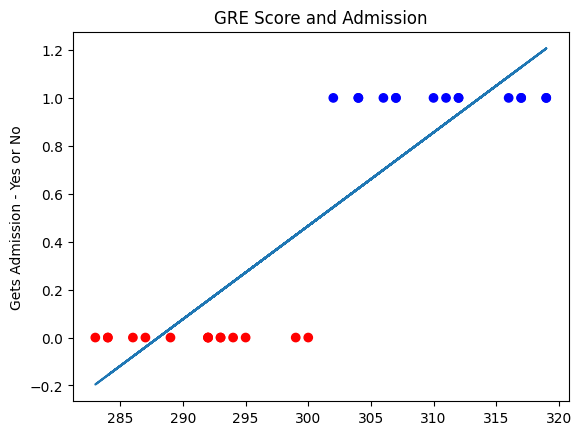

In [ ]:
plt.scatter(x,y, c=map_color[y.ravel()])
plt.plot(x, linear_reg.predict(x))
plt.title("GRE Score and Admission")
plt.ylabel("Gets Admission - Yes or No")
plt.show()

In [ ]:
# Logistic Regression
# import numpy as np
# def sigmoid(x):
#   return 1/(1+np.exp(-x))

In [ ]:
y_hat = linear_reg.predict(x)

In [ ]:
prob_y = sigmoid(y_hat)

In [ ]:
prob_y

array([[0.48998784],
       [0.56746495],
       [0.75553096],
       [0.614495  ],
       [0.70176329],
       [0.50945847],
       [0.53859234],
       [0.60522885],
       [0.48026021],
       [0.63277474],
       [0.45119618],
       [0.67674872],
       [0.71780529],
       [0.70984984],
       [0.76963023],
       [0.65068043],
       [0.54825514],
       [0.66817089],
       [0.53859234],
       [0.54825514],
       [0.53859234],
       [0.46085711],
       [0.76963023],
       [0.46085711],
       [0.65068043],
       [0.74826606],
       [0.55788169],
       [0.75553096],
       [0.71780529],
       [0.67674872]])

In [ ]:
threshold = 0.6
result = prob_y > 0.6
result.astype(int).flatten()

array([0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 0,
       1, 0, 1, 1, 0, 1, 1, 1])

In [ ]:
"""
Problem:
Predict passenger survival on the Titanic using demographic and travel features.

Type:
Binary Classification

Target Variable:
survived (0 = No, 1 = Yes)
"""

In [18]:
import pandas as pd
import seaborn as sns
titanic = sns.load_dataset("titanic")
titanic.to_csv("titanic.csv", index=False)

# Load CSV using pandas
df = pd.read_csv("titanic.csv")

In [19]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [20]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
886,0,2,male,27.0,0,0,13.00,S,Second,man,True,NaN,Southampton,no,True
887,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True
888,0,3,female,NaN,1,2,23.45,S,Third,woman,False,NaN,Southampton,no,False
889,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True
890,0,3,male,32.0,0,0,7.75,Q,Third,man,True,NaN,Queenstown,no,True


In [21]:
df.shape

(891, 15)

In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     891 non-null    int64  
 1   pclass       891 non-null    int64  
 2   sex          891 non-null    object 
 3   age          714 non-null    float64
 4   sibsp        891 non-null    int64  
 5   parch        891 non-null    int64  
 6   fare         891 non-null    float64
 7   embarked     889 non-null    object 
 8   class        891 non-null    object 
 9   who          891 non-null    object 
 10  adult_male   891 non-null    bool   
 11  deck         203 non-null    object 
 12  embark_town  889 non-null    object 
 13  alive        891 non-null    object 
 14  alone        891 non-null    bool   
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 92.4+ KB


In [23]:
df.describe()

,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [24]:
# Checking missing values
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [25]:
# Data Cleaning
# Select useful columns
features = ["pclass", "sex", "age", "fare", "embarked", "survived"]
df_model = df[features]

In [26]:
df_model

,pclass,sex,age,fare,embarked,survived
0,3,male,22.0,7.2500,S,0
1,1,female,38.0,71.2833,C,1
2,3,female,26.0,7.9250,S,1
3,1,female,35.0,53.1000,S,1
4,3,male,35.0,8.0500,S,0
...,...,...,...,...,...,...
886,2,male,27.0,13.0000,S,0
887,1,female,19.0,30.0000,S,1
888,3,female,NaN,23.4500,S,0
889,1,male,26.0,30.0000,C,1


In [27]:
df_model = df_model.copy()

df_model["age"] = df_model["age"].fillna(df_model["age"].median())
df_model["embarked"] = df_model["embarked"].fillna(df_model["embarked"].mode()[0])

In [28]:
# Encode categorical variables
df_model = pd.get_dummies(df_model, drop_first = True)
df_model.head()

,pclass,age,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,7.2500,0,True,False,True
1,1,38.0,71.2833,1,False,False,False
2,3,26.0,7.9250,1,False,False,True
3,1,35.0,53.1000,1,False,False,True
4,3,35.0,8.0500,0,True,False,True


In [29]:
df_model

,pclass,age,fare,survived,sex_male,embarked_Q,embarked_S
0,3,22.0,7.2500,0,True,False,True
1,1,38.0,71.2833,1,False,False,False
2,3,26.0,7.9250,1,False,False,True
3,1,35.0,53.1000,1,False,False,True
4,3,35.0,8.0500,0,True,False,True
...,...,...,...,...,...,...,...
886,2,27.0,13.0000,0,True,False,True
887,1,19.0,30.0000,1,False,False,True
888,3,28.0,23.4500,0,False,False,True
889,1,26.0,30.0000,1,True,False,False


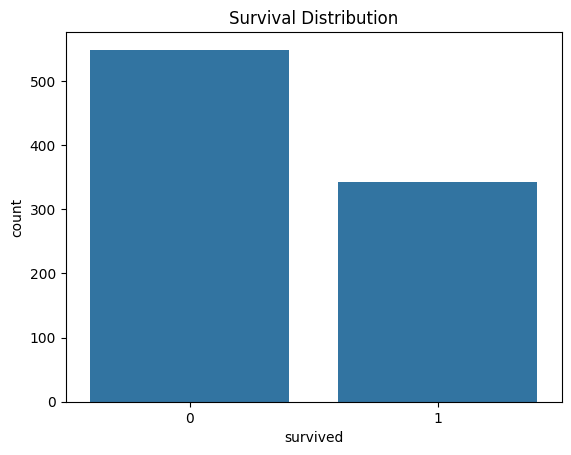

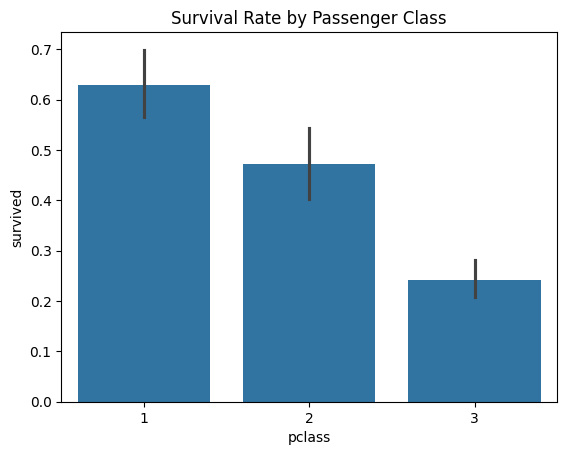

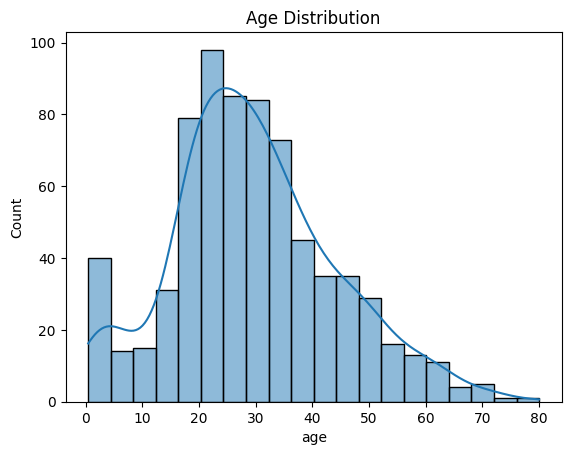

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt
# Survival Count
sns.countplot(x = "survived", data=df)
plt.title("Survival Distribution")
plt.show()

# Survival by Class
sns.barplot(x = "pclass", y = "survived", data=df)
plt.title("Survival Rate by Passenger Class")
plt.show()

# Age Distribution
sns.histplot(x = "age", data=df, kde = True)
plt.title("Age Distribution")
plt.show()

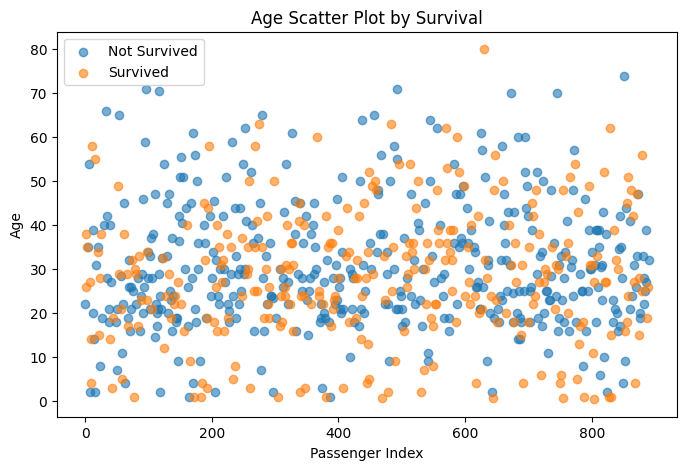

In [31]:
plt.figure(figsize=(8,5))
# Not survived (0) -> Red
plt.scatter(
    df[df["survived"] == 0].index,
    df[df["survived"] == 0]["age"],
    alpha = 0.6,
    label = "Not Survived"
)
# Survived (1) -> Blue
plt.scatter(
    df[df["survived"] == 1].index,
    df[df["survived"] == 1]["age"],
    alpha = 0.6,
    label = "Survived"
)
plt.title("Age Scatter Plot by Survival")
plt.xlabel("Passenger Index")
plt.ylabel("Age")
plt.legend()
plt.show()

In [32]:
# Data Modeling
# Split data and train a Logistic Regression Model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
X = df_model.drop("survived", axis =1)
y = df_model["survived"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state =42)
model = LogisticRegression(max_iter = 1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [33]:
X_train

,pclass,age,fare,sex_male,embarked_Q,embarked_S
331,1,45.5,28.5000,True,False,True
733,2,23.0,13.0000,True,False,True
382,3,32.0,7.9250,True,False,True
704,3,26.0,7.8542,True,False,True
813,3,6.0,31.2750,False,False,True
...,...,...,...,...,...,...
106,3,21.0,7.6500,False,False,True
270,1,28.0,31.0000,True,False,True
860,3,41.0,14.1083,True,False,True
435,1,14.0,120.0000,False,False,True


In [34]:
y_pred = model.predict(X_test)

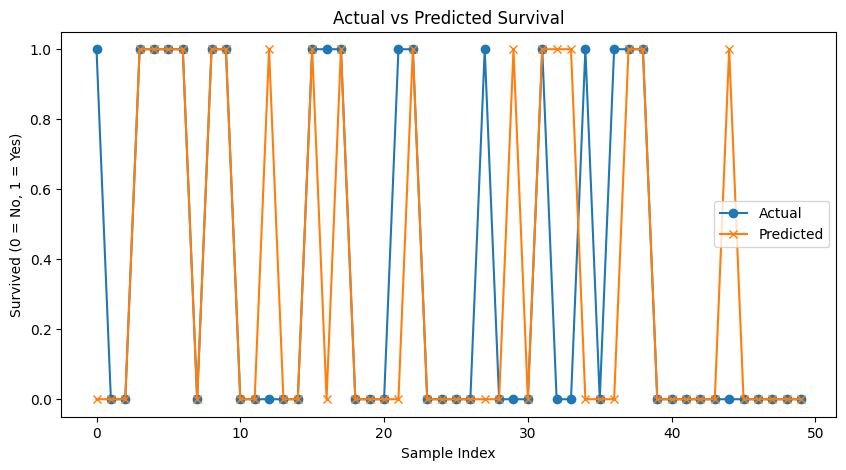

In [36]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.plot(y_test.values[:50], label="Actual", marker="o")
plt.plot(y_pred[:50], label="Predicted", marker="x")

plt.title("Actual vs Predicted Survival")
plt.xlabel("Sample Index")
plt.ylabel("Survived (0 = No, 1 = Yes)")
plt.legend()
plt.show()
